In [1]:
import os 
import sys
sys.path.append(os.path.abspath(".."))
from dotenv import load_dotenv
load_dotenv()

from typing import TypedDict
from langchain_core.messages import SystemMessage
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langchain_community.tools.tavily_search import TavilySearchResults

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.prebuilt import ToolNode

c:\Users\davis\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [2]:
#state
class AgentState(MessagesState):
    next_agent: str

In [3]:
llm = ChatOpenAI(
    model = "gpt-3.5-turbo"
)

In [4]:
@tool
def search_web(query: str) -> str:
    """Search the web for information"""
    search = TavilySearchResults(max_results=3)
    results = search.invoke(query)
    return str(results)

In [5]:
def supervisor_agent(state: AgentState):
    """Supervisor decides which agent should run next."""

    messages = state["messages"]

    system_msg = SystemMessage(
        content=(
            "You are a supervisor AI. Decide which agent should act next.\n"
            "Options:\n"
            "- researcher → if more information is needed\n"
            "- writer → if a summary or refinement is needed\n"
            "- end → if the task is complete\n"
            "Respond ONLY with one word: researcher, writer, or end."
        )
    )

    response = llm.invoke([system_msg] + messages)
    decision = response.content.strip().lower()

    if decision not in ["researcher", "writer", "end"]:
        decision = "writer"

    return {
        "messages": [response],
        "next_agent": decision
    }

In [6]:
def researcher_agent(state: AgentState):
    """Researcher agent that searches for information"""

    messages = state["messages"]

    system_msg = SystemMessage(
        content="You are a research assistant. Use the search_web tool to find relevant information."
    )

    researcher_llm = llm.bind_tools([search_web])
    response = researcher_llm.invoke([system_msg] + messages)

    # If tool call exists → route to tools
    if hasattr(response, "tool_calls") and response.tool_calls:
        return {
            "messages": [response],
            "next_agent": "tools"
        }

    # Otherwise → return to supervisor
    return {
        "messages": [response],
        "next_agent": "supervisor"
    }

In [7]:
def writer_agent(state: AgentState):
    """Writer agent that creates summary"""

    messages = state["messages"]

    system_message = SystemMessage(
        content="You are a technical writer. Create a clear, concise summary of the findings."
    )

    response = llm.invoke([system_message] + messages)

    return {
        "messages": [response],
        "next_agent": "supervisor"   
    }

###Build Graph

In [8]:
workflow = StateGraph(AgentState)

In [9]:
workflow.add_node("supervisor", supervisor_agent)
workflow.add_node("researcher", researcher_agent)
workflow.add_node("writer", writer_agent)
workflow.add_node("tools", ToolNode([search_web]))

In [10]:
workflow.add_edge(START, "supervisor")

workflow.add_conditional_edges(
    "supervisor",
    lambda state: state["next_agent"],
    {
        "researcher": "researcher",
        "writer": "writer",
        "end": END
    }
)

workflow.add_conditional_edges(
    "researcher",
    lambda state: state["next_agent"],
    {
        "tools": "tools",
        "supervisor": "supervisor"
    }
)

workflow.add_edge("tools", "supervisor")

workflow.add_edge("writer", "supervisor")

In [11]:
final_workflow = workflow.compile()

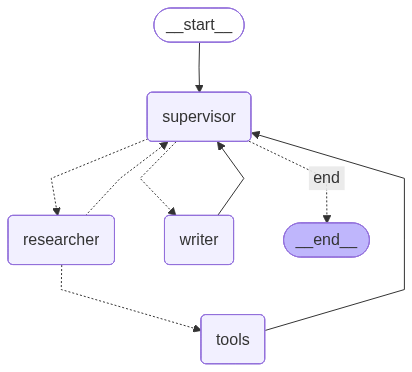

In [12]:
from IPython.display import Image, display

display(Image(final_workflow.get_graph().draw_mermaid_png())) 

In [13]:
response = final_workflow.invoke({
    "messages": "Research about the usecases of agentic AI in the IT industry"
})
print(response)

C:\Users\davis\AppData\Local\Temp\ipykernel_19744\3821390953.py:4: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  search = TavilySearchResults(max_results=3)


{'messages': [HumanMessage(content='Research about the usecases of agentic AI in the IT industry', additional_kwargs={}, response_metadata={}, id='31670161-d724-4bea-a188-fb3f8328ec99'), AIMessage(content='researcher', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 2, 'prompt_tokens': 81, 'total_tokens': 83, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-Djl04elVG6RQe98HBvn4PNTDzctT3', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e6437-88a4-7441-a390-c58f1f21c8c9-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 81, 'output_tokens': 2, 'total_tokens': 83, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'outpu

In [14]:
for msg in response["messages"]:
    msg.pretty_print()

================================ Human Message =================================

Research about the usecases of agentic AI in the IT industry
================================== Ai Message ==================================

researcher
================================== Ai Message ==================================
Tool Calls:
  search_web (call_mPwnjn92atmqRrTVq469ivqG)
 Call ID: call_mPwnjn92atmqRrTVq469ivqG
  Args:
    query: use cases of agentic AI in the IT industry
================================= Tool Message =================================
Name: search_web

[{'title': 'Agentic AI Use Cases That Prove the Power of Intelligent ...', 'url': 'https://www.moveworks.com/us/en/resources/blog/agentic-ai-examples-use-cases', 'content': "Table of contents\n\n## Highlights\n\n Agentic AI has rapidly evolved beyond traditional chatbots, enabling autonomous, multi-step workflow execution across enterprise systems.\n The highest-impact use cases share common traits: repetitive processes, 